# Кейс: Интерактивная аналитика цен на недвижимость в Великобритании

# Загрузка датасета, предобработка данных

1. Загрузим датасет из Kaggle:

In [ ]:
import kagglehub

path = kagglehub.dataset_download("willianoliveiragibin/uk-property-price-data-1995-2023-04")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/uk-property-price-data-1995-2023-04


2. Переименуем колонки (данные о значениях колонок взяты со страницы Kaggle), прочитаем 5 строк, убедимся, что все работает:

In [ ]:
import os
import pandas as pd
filename = "202304.csv"
cols = [
    'Transaction_ID', 'price', 'Date_of_Transfer', 'postcode',
    'Property_Type', 'Old/New', 'Duration', 'PAON', 'SAON',
    'Street', 'Locality', 'Town/City', 'District', 'County',
    'PPDCategory_Type', 'Record_Status'
]


full_path = os.path.join(path, filename)
chunk_size = 10000
df = pd.read_csv(full_path,  names=cols, nrows=5)
print(df.head())

                           Transaction_ID  price  Date_of_Transfer  postcode  \
0  {F887F88E-7D15-4415-804E-52EAC2F10958}  70000  1995-07-07 00:00  MK15 9HP   
1  {40FD4DF2-5362-407C-92BC-566E2CCE89E9}  44500  1995-02-03 00:00   SR6 0AQ   
2  {7A99F89E-7D81-4E45-ABD5-566E49A045EA}  56500  1995-01-13 00:00   CO6 1SQ   
3  {28225260-E61C-4E57-8B56-566E5285B1C1}  58000  1995-07-28 00:00   B90 4TG   
4  {444D34D7-9BA6-43A7-B695-4F48980E0176}  51000  1995-06-28 00:00   DY5 1SA   

  Property_Type Old/New Duration  PAON  SAON            Street       Locality  \
0             D       N        F    31   NaN     ALDRICH DRIVE         WILLEN   
1             T       N        F    50   NaN       HOWICK PARK     SUNDERLAND   
2             T       N        F    19   NaN  BRICK KILN CLOSE     COGGESHALL   
3             T       N        F    37   NaN  RAINSBROOK DRIVE        SHIRLEY   
4             S       N        F    59   NaN        MERRY HILL  BRIERLEY HILL   

       Town/City       District 

3. Выберем ненужные колонки: ID, SAON и тд., удалим их, посмотрим результат:

In [ ]:
columns_to_drop = [
        'Transaction_ID',
        'SAON',
        'Locality',
        'PPDCategory_Type',
        'Record_Status',
        'PAON',
        'Street'
]

# Drop the columns
df = df.drop(columns=columns_to_drop, errors='ignore')
df.head()

,price,Date_of_Transfer,postcode,Property_Type,Old/New,Duration,Town/City,District,County
0,70000,1995-07-07 00:00,MK15 9HP,D,N,F,MILTON KEYNES,MILTON KEYNES,MILTON KEYNES
1,44500,1995-02-03 00:00,SR6 0AQ,T,N,F,SUNDERLAND,SUNDERLAND,TYNE AND WEAR
2,56500,1995-01-13 00:00,CO6 1SQ,T,N,F,COLCHESTER,BRAINTREE,ESSEX
3,58000,1995-07-28 00:00,B90 4TG,T,N,F,SOLIHULL,SOLIHULL,WEST MIDLANDS
4,51000,1995-06-28 00:00,DY5 1SA,S,N,F,BRIERLEY HILL,DUDLEY,WEST MIDLANDS


4. Функции для оптимизации категориальных и числовых типов, удаления ненужных колонок.

In [ ]:
def optimize_dtypes(df):
    # Convert to appropriate types to reduce memory
    cat_cols = ['Property_Type', 'Old/New', 'Duration', 'postcode',
               'Town/City', 'District', 'County']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    if 'price' in df.columns:
        df['price'] = pd.to_numeric(df['price'], downcast='integer')

    return df

def remove_columns(df):
    # Remove less important columns
    cols_to_drop = [
        'Transaction_ID',
        'SAON',
        'Locality',
        'PPDCategory_Type',
        'Record_Status',
        'PAON',
        'Street'
    ]
    return df.drop(columns=[col for col in cols_to_drop if col in df.columns])


5. Функция обработки данных за определенный период

In [ ]:
def process_period(start_year, end_year, input_path, output_folder):
    output_path = f"{output_folder}/property_prices_{start_year}_{end_year}.csv"
    print(f"Processing {start_year}-{end_year}...")

    first_chunk = True
    for chunk in pd.read_csv(input_path, names=cols, chunksize=100000):
        chunk['Date_of_Transfer'] = pd.to_datetime(chunk['Date_of_Transfer'])

        chunk = chunk[
            (chunk['Date_of_Transfer'] >= datetime(start_year, 1, 1)) &
            (chunk['Date_of_Transfer'] <= datetime(end_year, 12, 31))
        ]

        if len(chunk) == 0:
            continue

        chunk = optimize_dtypes(chunk)
        chunk = remove_columns(chunk)

        chunk.to_csv(output_path, mode='a', index=False, header=first_chunk)
        first_chunk = False


    if os.path.exists(output_path):
        size_mb = os.path.getsize(output_path)/(1024*1024)
        row_count = len(pd.read_csv(output_path))
        print(f"Saved {row_count:,} rows ({size_mb:.1f} MB) to {output_path}")
    else:
        print(f"No data found for {start_year}-{end_year}")

# Рассмотрим данные с 1998 по 2010 год: отразим кризис 2008 года и проанализируем зависимость спроса и цен от глобальных экономических факторов, рассмотрим поведение рынка во время крупных экономических кризисов.

In [ ]:
import os
from datetime import datetime
start_year = 1998
end_year = 2010
process_period(start_year, end_year, full_path, "/content")
print("\nAll processing complete!")


Processing 1998-2010...
Saved 14,035,595 rows (889.0 MB) to /content/property_prices_1998_2010.csv

All processing complete!


In [ ]:
df = pd.read_csv("/content/property_prices_1998_2010.csv")
df.head()

,price,Date_of_Transfer,postcode,Property_Type,Old/New,Duration,Town/City,District,County
0,53000,1998-01-09,WA5 3PY,S,N,F,WARRINGTON,WARRINGTON,WARRINGTON
1,51000,1998-08-28,SA62 6TP,S,N,F,HAVERFORDWEST,PEMBROKESHIRE,PEMBROKESHIRE
2,43250,1998-07-15,DL8 1EW,F,N,L,BEDALE,HAMBLETON,NORTH YORKSHIRE
3,28250,1998-03-25,LE10 0EY,S,N,F,HINCKLEY,HINCKLEY AND BOSWORTH,LEICESTERSHIRE
4,59950,1998-02-27,CF15 9JP,T,N,F,CARDIFF,CARDIFF,CARDIFF


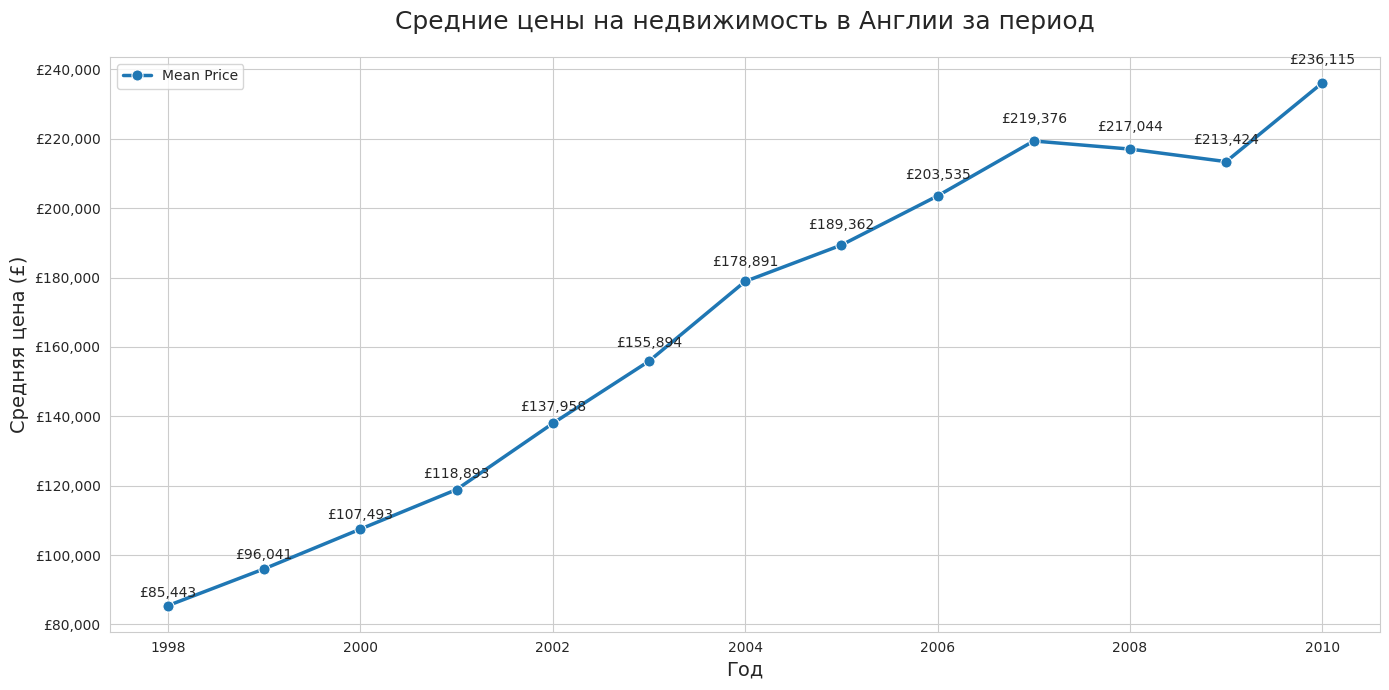


Статистика:
 Year  Mean_Price  Transaction_Count
 1998    85443.45            1050306
 1999    96040.98            1194681
 2000   107492.80            1129173
 2001   118893.30            1245641
 2002   137958.26            1351596
 2003   155894.17            1235241
 2004   178891.18            1231722
 2005   189361.52            1061260
 2006   203535.32            1325879
 2007   219376.45            1272132
 2008   217043.70             649549
 2009   213423.73             625208
 2010   236114.68             663207


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
def calculate_annual_mean_prices(df):
    annual_data = df.groupby('Year').agg({
        'price': ['mean', 'count'],
    }).reset_index()

    annual_data.columns = ['Year', 'Mean_Price', 'Transaction_Count']
    annual_data['Mean_Price'] = annual_data['Mean_Price'].round(2)
    return annual_data

def plot_mean_prices(annual_data):
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    ax1 = sns.lineplot(
        x='Year',
        y='Mean_Price',
        data=annual_data,
        marker='o',
        markersize=8,
        linewidth=2.5,
        color='#1f77b4',
        label='Mean Price'
    )

    ax1.set_title('Cредние цены на недвижимость в Англии за период', fontsize=18, pad=20)
    ax1.set_xlabel('Год', fontsize=14)
    ax1.set_ylabel('Средняя цена (£)', fontsize=14)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{x:,.0f}"))

    for index, row in annual_data.iterrows():
        ax1.text(
            row['Year'],
            row['Mean_Price'] * 1.02,
            f"£{row['Mean_Price']:,.0f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc='upper left')

    plt.tight_layout()
    plt.show()

df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Year'] = df['Date_of_Transfer'].dt.year

annual_stats = calculate_annual_mean_prices(df)
plot_mean_prices(annual_stats)


print("\nСтатистика:")
print(annual_stats.to_string(index=False))

Данный график отражает изменение средней цены на недвижимость с течением времени за этот период. Видно, что цены стабильно и быстро растут, переживая небольшой спад в районе 2007-2010 годов.

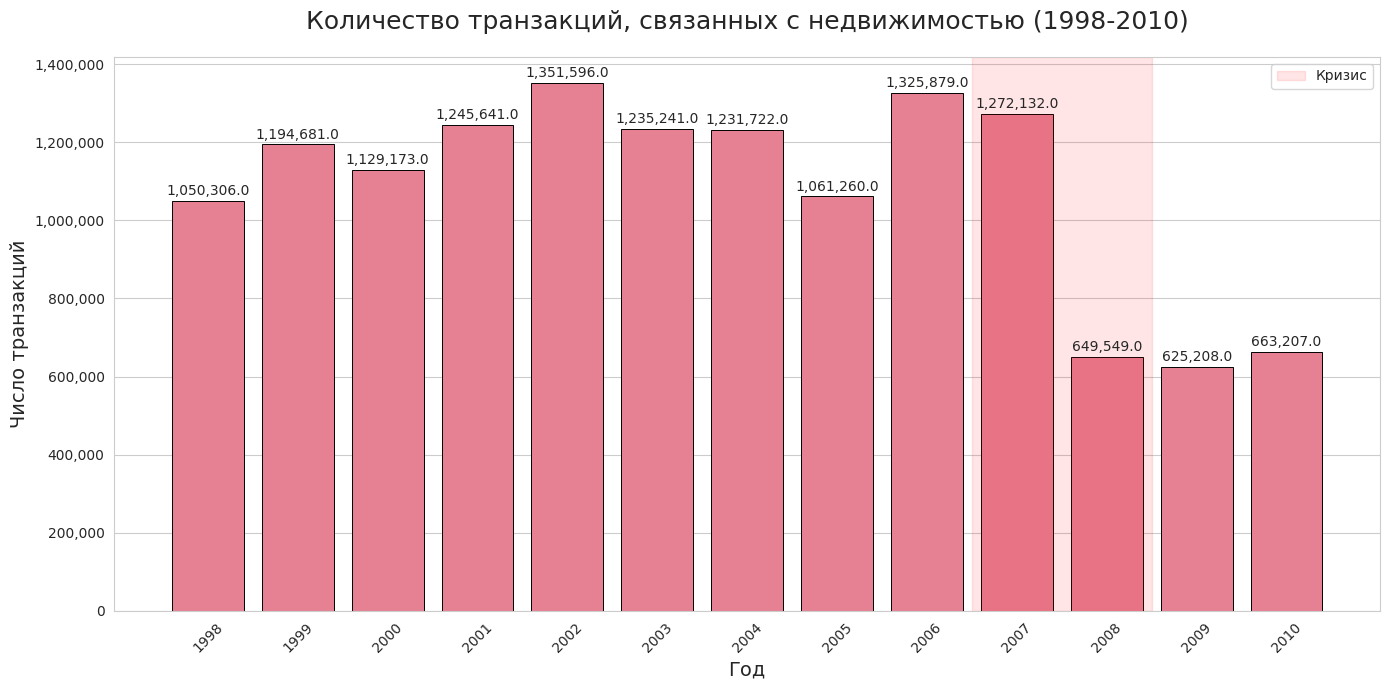

In [ ]:
transactions_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.set_palette("husl")

# Bar plot with improved styling
ax = sns.barplot(x=transactions_per_year.index,
                 y=transactions_per_year.values,
                 edgecolor='black',
                 linewidth=0.7)

# Customizations
plt.title('Количество транзакций, связанных с недвижимостью (1998-2010)', fontsize=18, pad=20)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Число транзакций', fontsize=14)
plt.xticks(rotation=45)

# Format y-axis with thousands separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add precise value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=10)


ax.axvspan(8.5, 10.5, color='red', alpha=0.1, label='Кризис')
plt.legend()

plt.tight_layout()
plt.show()


В количестве транзакций очевиден катастрофический спад интереса к недвижимости, связанный с финансовым кризисом.

Вывод по рассмотренным данным:
Глобальные экономические факторы (такие, как кризис 2008 года) сильно влияют на спрос на недвижимость, и спрос мало зависит от цен на нее. Возможно, цены на недвижимость коореллируют с каким-то другим показателем.

#Рассмотрим данные с 2011 по 2023 года: проанализируем новейшие данные, определим тенденции современного рынка, определим влияние Коронавируса и прочих геополитических событий на рынок Англии.

In [ ]:
start_year = 2011
end_year = 2023
process_period(start_year, end_year, full_path, "/content")
print("\nAll processing complete!")

Processing 2011-2023...
Saved 11,384,417 rows (729.4 MB) to /content/property_prices_2011_2023.csv

All processing complete!


In [ ]:
df = pd.read_csv("/content/property_prices_2011_2023.csv")
df.head()

,price,Date_of_Transfer,postcode,Property_Type,Old/New,Duration,Town/City,District,County
0,451203,2011-11-22,BS1 6JU,F,Y,L,BRISTOL,CITY OF BRISTOL,CITY OF BRISTOL
1,121000,2011-06-02,S80 4PE,S,N,F,WORKSOP,BOLSOVER,DERBYSHIRE
2,247500,2011-11-18,CF15 8AE,S,N,F,CARDIFF,CARDIFF,CARDIFF
3,190000,2011-07-01,EX13 5FJ,T,Y,F,AXMINSTER,EAST DEVON,DEVON
4,116400,2011-06-30,WA13 0JY,F,N,L,LYMM,WARRINGTON,WARRINGTON


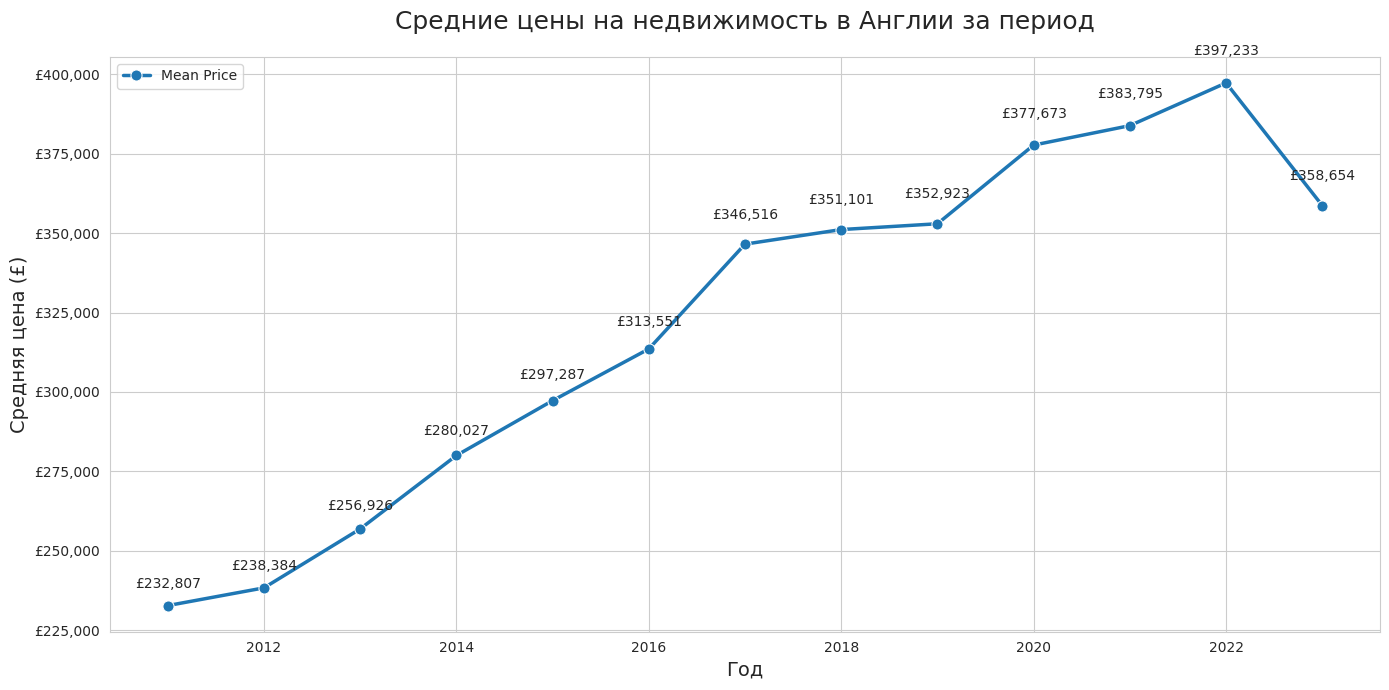


Статистика:
 Year  Mean_Price  Transaction_Count
 2011   232807.38             661126
 2012   238384.15             668809
 2013   256926.42             810871
 2014   280026.57             984659
 2015   297286.64            1010416
 2016   313550.63            1045377
 2017   346515.73            1065840
 2018   351101.07            1035342
 2019   352923.06            1007770
 2020   377673.44             882717
 2021   383795.47            1220166
 2022   397233.06             862421
 2023   358654.04             128903


In [ ]:
df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Year'] = df['Date_of_Transfer'].dt.year

annual_stats = calculate_annual_mean_prices(df)
plot_mean_prices(annual_stats)


print("\nСтатистика:")
print(annual_stats.to_string(index=False))

Очевидно, что цены на недвижимость в Англии продолжают показывать стабильный рост.

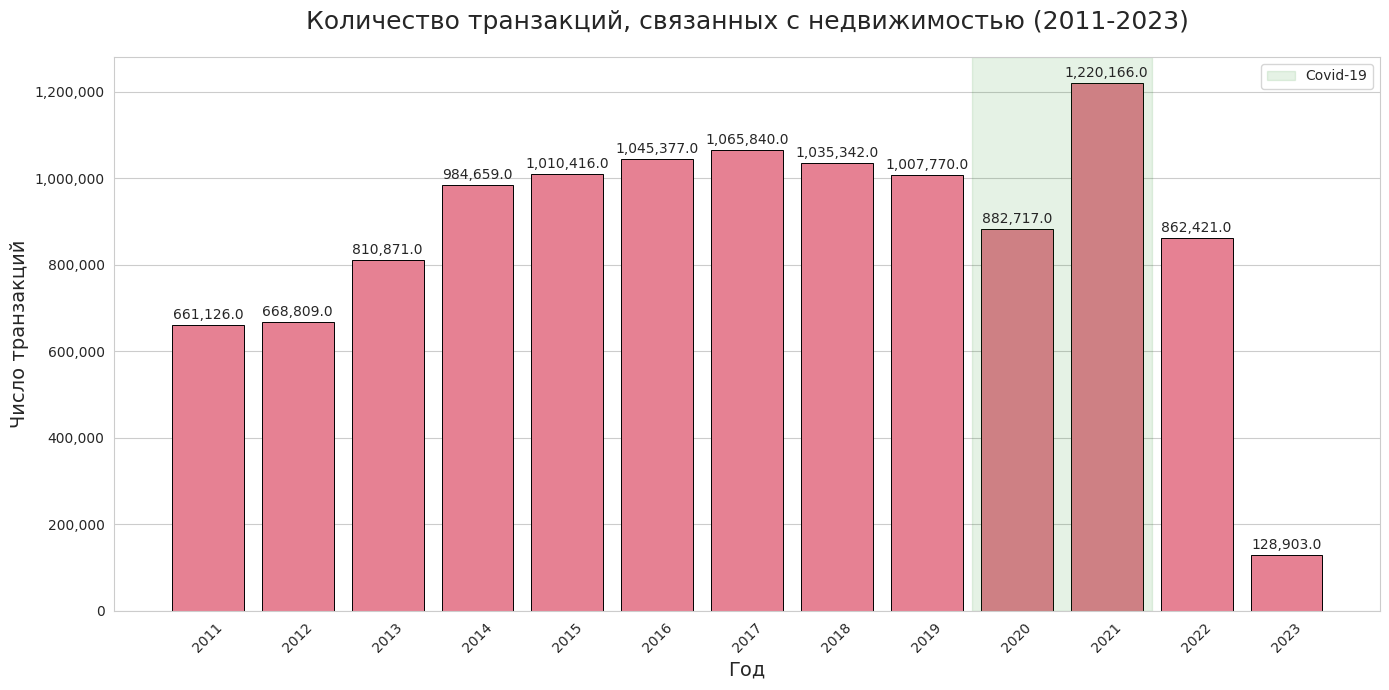

In [ ]:

transactions_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.set_palette("husl")

ax = sns.barplot(x=transactions_per_year.index,
                 y=transactions_per_year.values,
                 edgecolor='black',
                 linewidth=0.7)

plt.title('Количество транзакций, связанных с недвижимостью (2011-2023)', fontsize=18, pad=20)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Число транзакций', fontsize=14)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=10)


ax.axvspan(8.5, 10.5, color='green', alpha=0.1, label='Covid-19')
plt.legend()

plt.tight_layout()
plt.show()


Спрос на недвижимость после пост-кризисного провала вернулся к значениям чуть ниже значений до кризиса. Видны минимум и максимум, связаные с пандемией.

# Рассмотрение зависимости популярности и цен на жилье от процентной ставки Англии

Загрузим новый датасет, содержащий данные о процентной ставке банка Англии за период 1975-2022:

In [ ]:
path = kagglehub.dataset_download("samuelcortinhas/bank-of-england-interest-rates-19752021")
filename = "Bank Rate history and data  Bank of England Database.csv"
print("Path to dataset files:", path)
full_path = os.path.join(path, filename)
ir_df = pd.read_csv(full_path)
ir_df.head()

Path to dataset files: /kaggle/input/bank-of-england-interest-rates-19752021


,Date Changed,Rate
0,03 Nov 22,3.00
1,22 Sep 22,2.25
2,04 Aug 22,1.75
3,16 Jun 22,1.25
4,05 May 22,1.00


Используем более новые данные (2011 - 2023) для сравнения.

In [ ]:
df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Year'] = df['Date_of_Transfer'].dt.year
df['Month'] = df['Date_of_Transfer'].dt.to_period('M')
df.head()

,price,Date_of_Transfer,postcode,Property_Type,Old/New,Duration,Town/City,District,County,Year,Month
0,451203,2011-11-22,BS1 6JU,F,Y,L,BRISTOL,CITY OF BRISTOL,CITY OF BRISTOL,2011,2011-11
1,121000,2011-06-02,S80 4PE,S,N,F,WORKSOP,BOLSOVER,DERBYSHIRE,2011,2011-06
2,247500,2011-11-18,CF15 8AE,S,N,F,CARDIFF,CARDIFF,CARDIFF,2011,2011-11
3,190000,2011-07-01,EX13 5FJ,T,Y,F,AXMINSTER,EAST DEVON,DEVON,2011,2011-07
4,116400,2011-06-30,WA13 0JY,F,N,L,LYMM,WARRINGTON,WARRINGTON,2011,2011-06


<ipython-input-26-2964840629>:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ir_df['Date'] = pd.to_datetime(ir_df['Date Changed'])


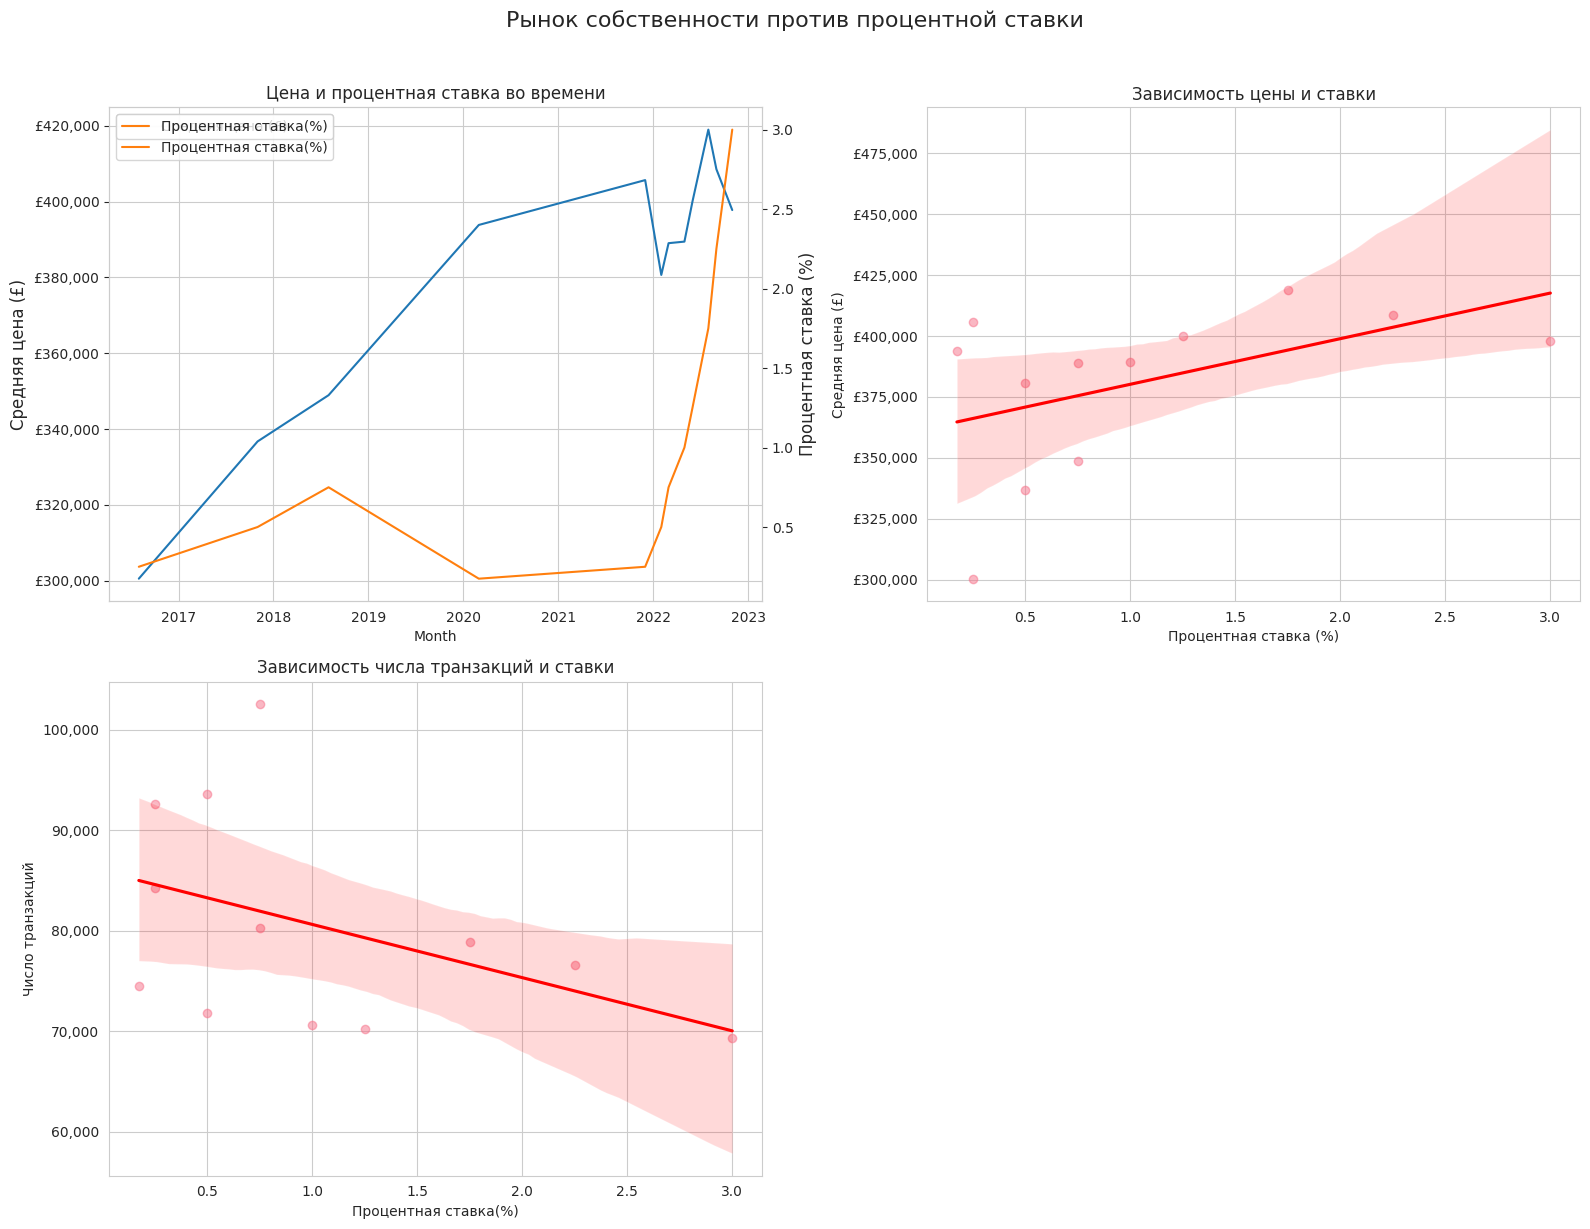

In [ ]:
def analyze_relationship(prop_df, rates_df):
    prop_df['Month'] = pd.to_datetime(prop_df['Date_of_Transfer']).dt.to_period('M').dt.to_timestamp()
    monthly_counts = prop_df.groupby('Month').size().reset_index(name='Transaction_Count')
    monthly_prices = prop_df.groupby('Month')['price'].mean().reset_index()

    monthly_props = pd.merge(monthly_counts, monthly_prices, on='Month')
    rates_df['Month'] = pd.to_datetime(rates_df['Date']).dt.to_period('M').dt.to_timestamp()
    monthly_rates = rates_df.groupby('Month')['Rate'].mean().reset_index()
    monthly_rates.columns = ['Month', 'Rate']

    merged = pd.merge(monthly_props, monthly_rates, on='Month', how='inner')
    return merged

def create_visualizations(merged_df):
    plt.figure(figsize=(16, 12))
    sns.set_style("whitegrid")
    plt.suptitle("Рынок собственности против процентной ставки", y=1.02, fontsize=16)
    plt.subplot(2, 2, 1)
    ax1 = sns.lineplot(x='Month', y='price', data=merged_df,
                     color='#1f77b4', label='Средняя цена (£)')
    ax1.set_ylabel("Средняя цена (£)", fontsize=12)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{x:,.0f}"))

    ax2 = ax1.twinx()
    sns.lineplot(x='Month', y='Rate', data=merged_df,
               color='#ff7f0e', ax=ax2, label='Процентная ставка(%)')
    ax2.set_ylabel("Процентная ставка (%)", fontsize=12)
    ax2.grid(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.title("Цена и процентная ставка во времени")

    plt.subplot(2, 2, 2)
    sns.regplot(x='Rate', y='price', data=merged_df,
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.xlabel("Процентная ставка (%)")
    plt.ylabel("Средняя цена (£)")
    plt.title("Зависимость цены и ставки")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{x:,.0f}"))

    plt.subplot(2, 2, 3)
    sns.regplot(x='Rate', y='Transaction_Count', data=merged_df,
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.xlabel("Процентная ставка(%)")
    plt.ylabel("Число транзакций")
    plt.title("Зависимость числа транзакций и ставки")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()
property_data = df.copy()

ir_df['Date'] = pd.to_datetime(ir_df['Date Changed'])
merged_data = analyze_relationship(property_data, ir_df)
create_visualizations(merged_data)

#print("\nКорелляция:")
#print(f"Цены и ставки: {merged_data['price'].corr(merged_data['Rate']):.3f}")
#print(f"Числа и ставки: {merged_data['Transaction_Count'].corr(merged_data['Rate']):.3f}")


Процентная ставка как показатель здоровья экономики позволяет достаточно точно строить предположения о характере роста или падения цен на недвижимость, а также с меньшей, но существенной точностью прогнозировать спрос на недвижимость. Цена с ростом ставки растет, а активность рынка падает. Еще лучше коорелляция видна в более короткие промежутки времени, что отражено в нашем дэшборде Yandex DataLens. (ссылка?)

# Вывод

При стабильной геополитической ситуации (подобной 2010-20 годам) рынок недвижимости Англии также крайне стабилен. На экономическую ситуацию в стране влияют макроэкономические факторы, и текущая геополитическая и макроэкономическая обстановка "Стабильными" не являются, что выражается в том числе в очень быстром росте процентной ставки в Англии.

Процентная ставка, которую мы рассматриваем как достаточно точный показатель нестабильности экономики по сей день демонстрирует стремительный рост: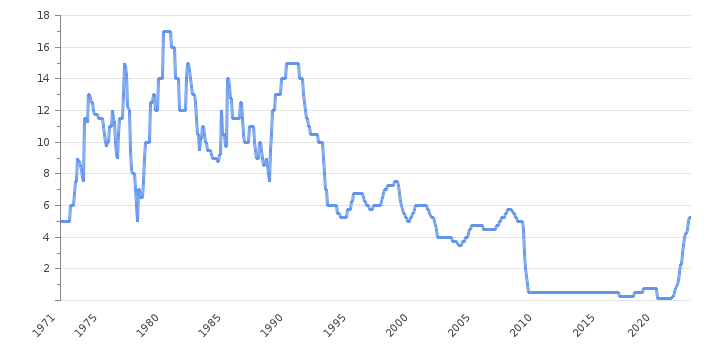


С 2020-21 процентная ставка растет, мы предполагаем, что между ней и Ценой прослеживается коореляция, следовательно, цена на недвижимость с 2020 года должна расти намного быстрее обычного, что подтверждается реальными данными:
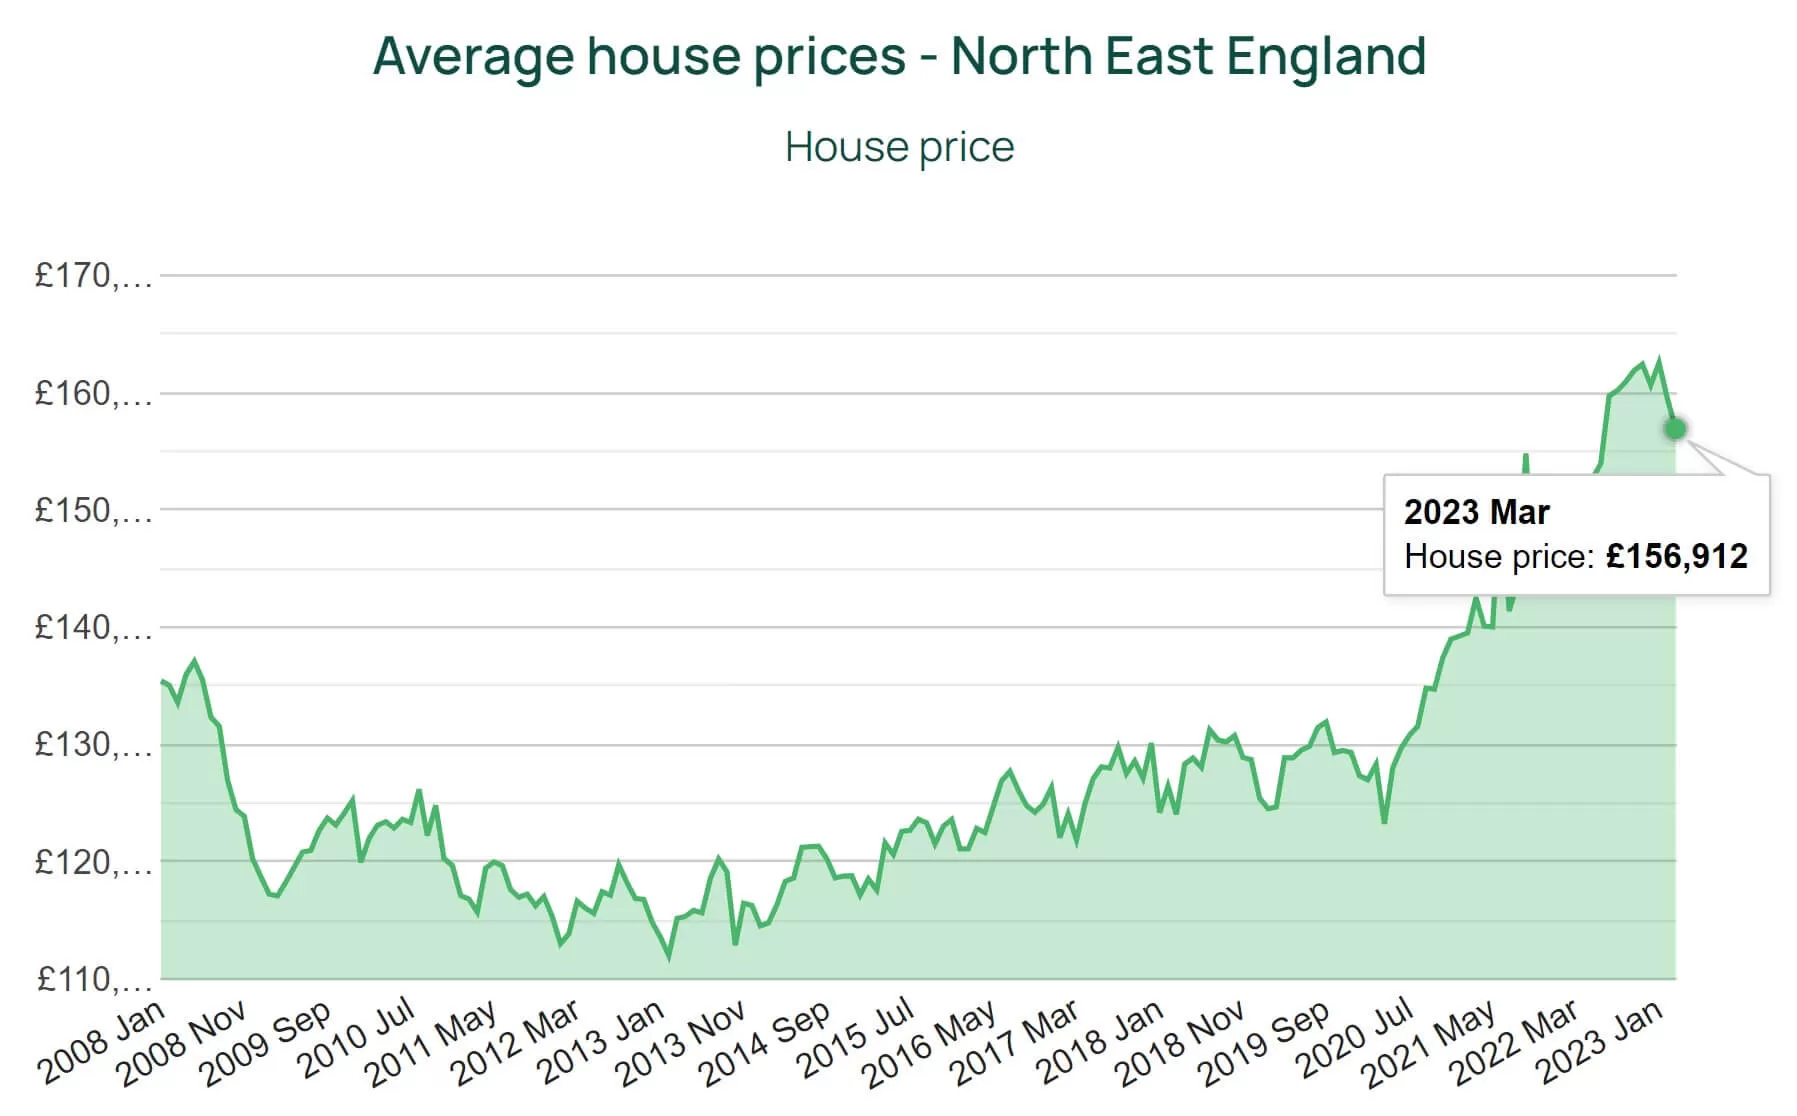

Рост процентной ставки означает рост цен на недвижимость, однако с сезонным и вызванным повышением цен падением спроса цены могут также демонстрировать огромные сезонные падения. Высокая процентная ставка показывает высокий риск и нестабильность. Наверняка сказать, продолжат ли цены расти в будущем сложно, особенно учитывая отсутствие данных за последние два года в рабочем датасете.

Традиционно Англия считается хорошей целью инвестирования, но текущее состояние рынка, сильно отличное от стабильного состояния 2010-2020 гг и макроэкономические и геополитические факторы ставят это утверждение под вопрос. Мы видим ситуацию как нестабильную, но тем не менее, вывод сильно зависит от региона, типа недвижимости и текущей ситуации. Для формирования однозначных выводов требуются **Более современные данные**, большее их количество и большее количество ресурсов, **В том числе опыта и времени** (можно удалить).